# CHB-MIT eeg dataset seizure detection demo
This notebook is demo for seizure detection using CHB-MIT eeg dataset.  
In this notebook, deep learning model with 2d CNN is buit for seizure detection.  
Keras is used for deep learning platform.  

In [3]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2
!pip install numpy==1.22.4

Found existing installation: torch 2.0.0
Uninstalling torch-2.0.0:
  Successfully uninstalled torch-2.0.0
Found existing installation: torchvision 0.15.1
Uninstalling torchvision-0.15.1:
  Successfully uninstalled torchvision-0.15.1
Found existing installation: torchaudio 2.0.1
Uninstalling torchaudio-2.0.1:
  Successfully uninstalled torchaudio-2.0.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 86.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 89.0 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 66.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 65.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

**xử lý'**

In [4]:


import numpy as np
import matplotlib.pyplot as plt
import wfdb
import glob
import random
import gc
import mne
from scipy.signal import resample
import tqdm
import logging
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
import torch
from torch.utils.data import DataLoader, TensorDataset

mne.set_log_level(verbose='ERROR')

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 
             'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-1', 'P8-O2', 
             'FZ-CZ', 'CZ-PZ']  # Đã sửa 'T8-P8-0' thành 'T8-P8'

path2pt = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'

def check_data(X, Y=None, stage="Raw"):
    print(f"[{stage} Data]")
    print(f"Shape of X: {X.shape}")
    if Y is not None:
        print(f"Shape of Y: {Y.shape}")
    print(f"Sample X[0, 0, :10]: {X[0, 0, :10]}")
    if Y is not None:
        print(f"Sample Y[0]: {Y[0]}")
    print(f"Min value: {X.min()}, Max value: {X.max()}")
    if np.any(X > 0):
        print(f"Number of spikes (if encoded): {X.sum()}\n")
    else:
        print("\n")

def normalize_data(X):
    X_min = X.min(axis=(0, 2), keepdims=True)
    X_max = X.max(axis=(0, 2), keepdims=True)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-8)
    return X_normalized

def rate_encoding(signal, threshold=None, return_threshold=False):
    if threshold is None:
        threshold = np.mean(signal) + 2 * np.std(signal)  # Tính threshold

    spikes = np.zeros_like(signal)  # Mảng spike ban đầu toàn 0
    spikes[(signal > threshold) & (signal >= 0.65)] = 1  # Chỉ spike khi > threshold & >= 0.6

    if return_threshold:
        return spikes, threshold
    return spikes

mne.set_log_level(verbose='ERROR')

def process_and_save_file(temp_f, ch_labels, time_window, time_step, downsample_factor, output_dir):
    temp_edf = mne.io.read_raw_edf(temp_f, preload=False)
    temp_labels = temp_edf.ch_names

    if all(any(ch in l for l in temp_labels) for ch in ch_labels):
        temp_edf.pick(ch_labels)
        temp_signals = temp_edf.get_data() * 1e6
        temp_len = temp_edf.n_times
        fs = int(1 / (temp_edf.times[1] - temp_edf.times[0]))

        new_timesteps = temp_len // downsample_factor
        temp_signals = resample(temp_signals, num=new_timesteps, axis=1)

        temp_is_sz = np.zeros(new_timesteps)
        if os.path.exists(temp_f + '.seizures'):
            temp_annotation = wfdb.rdann(temp_f, 'seizures')
            for i in range(int(temp_annotation.sample.size / 2)):
                start = temp_annotation.sample[i*2] // downsample_factor
                end = temp_annotation.sample[i*2+1] // downsample_factor
                temp_is_sz[start:end] = 1

        step_window = time_window * fs // downsample_factor
        step = time_step * fs // downsample_factor
        temp_is_sz_ind = np.array(
            [temp_is_sz[i*step:i*step+step_window].sum() / step_window 
             for i in range((new_timesteps - step_window) // step)]
        )

        temp_0_sample_size = round(0.5 * np.where(temp_is_sz_ind == 0)[0].size)
        temp_1_sample_size = np.where(temp_is_sz_ind > 0)[0].size
        total_samples = temp_0_sample_size + temp_1_sample_size

        if total_samples > 0:
            array_signals = np.zeros((total_samples, len(ch_labels), step_window), dtype=np.float32)
            array_is_sz = np.zeros(total_samples, dtype=bool)

            counter = 0
            temp_ind = list(np.where(temp_is_sz_ind > 0)[0])
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = True
                counter += 1

            temp_ind = random.sample(list(np.where(temp_is_sz_ind == 0)[0]), temp_0_sample_size)
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = False
                counter += 1

            array_signals = normalize_data(array_signals)
            array_spikes = rate_encoding(array_signals)
            
            np.save(os.path.join(output_dir, f"signals_{os.path.basename(temp_f)}.npy"), array_spikes)
            np.save(os.path.join(output_dir, f"labels_{os.path.basename(temp_f)}.npy"), array_is_sz)

            return True
    temp_edf.close()
    return False

def preprocess_chb_mit_data(path, ch_labels, downsample_factor=5, time_window=8, time_step=4, test_size=0.3, initial_balance_ratio=10):
    folders = sorted(glob.glob(path + '/*/'))
    folders = [folder for folder in folders if 'chb24' not in folder]
    
    n_patient = [folder.split('/')[-2][-2:] for folder in folders]
    random.seed(2023)
    ratio_train = 0.8
    train_patient_str = sorted(random.sample(n_patient, round(ratio_train * len(n_patient))))
    test_patient_str = sorted([pt for pt in n_patient if pt not in train_patient_str])
    print('Train PT:', *train_patient_str)
    print('Test PT:', *test_patient_str)

    files_train = [file for pt in train_patient_str for file in glob.glob(f'{path}/chb{pt}/*.edf')]
    print("Number of training files:", len(files_train))

    output_dir = "temp_chb_mit_data"
    os.makedirs(output_dir, exist_ok=True)

    valid_files = 0
    for temp_f in tqdm.tqdm(files_train):
        if process_and_save_file(temp_f, ch_labels, time_window, time_step, downsample_factor, output_dir):
            valid_files += 1
        gc.collect()

    print(f"Number of valid files processed: {valid_files}")

    all_spikes = []
    all_labels = []
    for temp_f in files_train:
        signal_file = os.path.join(output_dir, f"signals_{os.path.basename(temp_f)}.npy")
        label_file = os.path.join(output_dir, f"labels_{os.path.basename(temp_f)}.npy")
        if os.path.exists(signal_file) and os.path.exists(label_file):
            spikes = np.load(signal_file)
            labels = np.load(label_file)

            label_0_indices = np.where(labels == 0)[0]
            label_1_indices = np.where(labels == 1)[0]
            n_label_1 = len(label_1_indices)
            n_label_0_new = min(n_label_1 * initial_balance_ratio, len(label_0_indices))

            label_0_sampled_indices = np.random.choice(label_0_indices, n_label_0_new, replace=False)
            balanced_indices = np.concatenate((label_0_sampled_indices, label_1_indices))
            np.random.shuffle(balanced_indices)

            spikes_balanced = spikes[balanced_indices]
            labels_balanced = labels[balanced_indices]

            all_spikes.append(spikes_balanced)
            all_labels.append(labels_balanced)
            del spikes, labels, spikes_balanced, labels_balanced
            gc.collect()

    X_initial_balanced = np.concatenate(all_spikes, axis=0)
    Y_initial_balanced = np.concatenate(all_labels, axis=0)
    check_data(X_initial_balanced, Y_initial_balanced, "After Initial Balancing (10:1)")

    n_label_0 = np.sum(Y_initial_balanced == 0)
    target_n_label_1 = int(0.7 * n_label_0)

    ros = RandomOverSampler(random_state=42, sampling_strategy={0: n_label_0, 1: target_n_label_1})
    X_flat = X_initial_balanced.reshape(X_initial_balanced.shape[0], -1)
    X_resampled, Y_resampled = ros.fit_resample(X_flat, Y_initial_balanced)
    X_balanced = X_resampled.reshape(-1, 18, X_initial_balanced.shape[2])
    check_data(X_balanced, Y_resampled, "After Oversampling (Class 1 ~ 70% Class 0)")

    X_train, X_val, Y_train, Y_val = train_test_split(
        X_balanced, Y_resampled, test_size=test_size, stratify=Y_resampled, random_state=42
    )

    class_weights = compute_class_weight('balanced', classes=[0, 1], y=Y_train)
    print(f"Class weights: {class_weights}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_train_tensor = torch.FloatTensor(X_train).permute(0, 2, 1).to(device)
    Y_train_tensor = torch.FloatTensor(Y_train).to(device)
    train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)

    X_val_tensor = torch.FloatTensor(X_val).permute(0, 2, 1).to(device)
    Y_val_tensor = torch.FloatTensor(Y_val).to(device)
    val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=200, shuffle=False)

    X_full = np.concatenate((X_train, X_val), axis=0)
    Y_full = np.concatenate((Y_train, Y_val), axis=0)
    np.save("processed_eeg_spikes_balanced_70pct.npy", X_full)
    np.save("processed_labels_balanced_70pct.npy", Y_full)

    return train_loader, val_loader, class_weights, X_train.shape[1], X_train.shape[2], X_train, X_val, Y_train, Y_val

if __name__ == "__main__":
    train_loader, val_loader, class_weights, input_channels, input_timesteps, X_train, X_val, Y_train, Y_val = preprocess_chb_mit_data(
        path2pt, ch_labels, downsample_factor=5, time_window=14, time_step=4, test_size=0.3, initial_balance_ratio=10
    )

    print(f"Input channels: {input_channels}, Input timesteps: {input_timesteps}")

Train PT: 02 03 04 05 06 09 11 12 13 14 15 16 17 18 19 20 21 23
Test PT: 01 07 08 10 22
Number of training files: 527


100%|██████████| 527/527 [22:05<00:00,  2.51s/it]  


Number of valid files processed: 496
[After Initial Balancing (10:1) Data]
Shape of X: (24008, 18, 716)
Shape of Y: (24008,)
Sample X[0, 0, :10]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sample Y[0]: False
Min value: 0.0, Max value: 1.0
Number of spikes (if encoded): 5226502.0

[After Oversampling (Class 1 ~ 70% Class 0) Data]
Shape of X: (36504, 18, 716)
Shape of Y: (36504,)
Sample X[0, 0, :10]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sample Y[0]: False
Min value: 0.0, Max value: 1.0
Number of spikes (if encoded): 10239008.0

Class weights: [0.84997671 1.21433324]
Input channels: 18, Input timesteps: 716


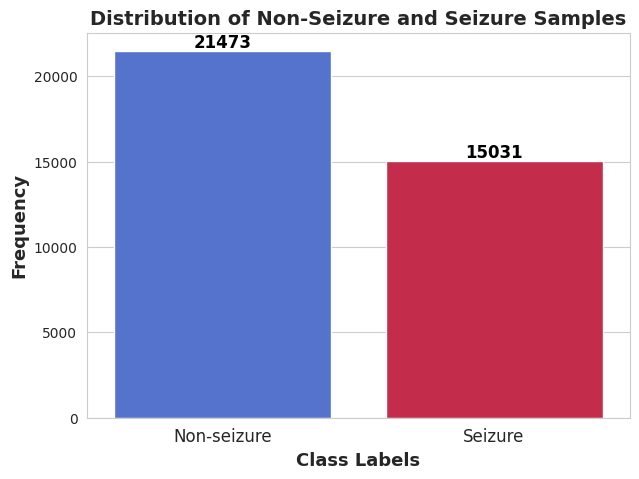

Saved: label_distribution_improved.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load labels
Y = np.load("/kaggle/working/processed_labels_balanced_70pct.npy", allow_pickle=True)

# Đếm số lượng mẫu từng lớp
unique, counts = np.unique(Y, return_counts=True)
class_counts = dict(zip(unique, counts))

# Cấu hình seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

# Vẽ barplot
colors = ['royalblue', 'crimson']
ax = sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=colors)

# Gán nhãn trên từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Thiết lập trục và tiêu đề
plt.xticks([0, 1], labels=['Non-seizure', 'Seizure'], fontsize=12)
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.ylabel("Frequency", fontsize=13, fontweight='bold')
plt.title("Distribution of Non-Seizure and Seizure Samples", fontsize=14, fontweight='bold')

# Lưu hình ảnh
save_path = "label_distribution_improved.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")


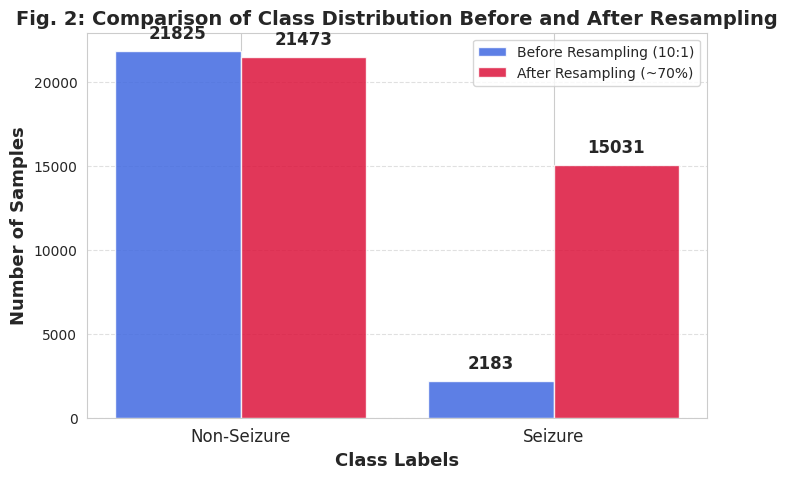

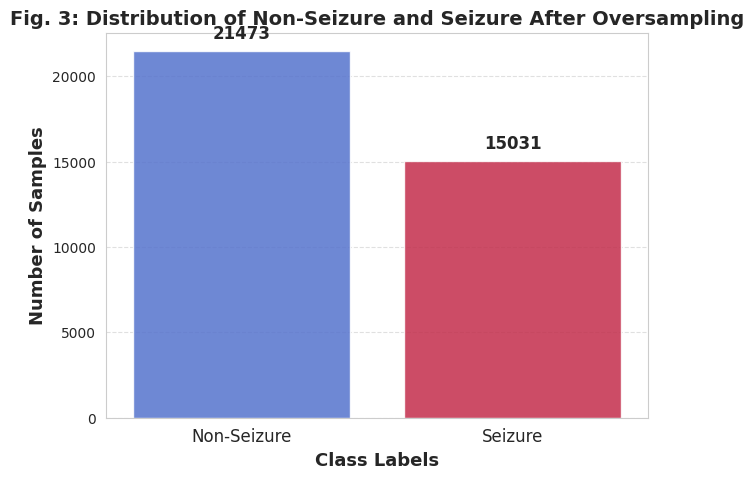

Saved: class_distribution_comparison_improved.png, class_distribution_after_oversampling_improved.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Số lượng mẫu trước và sau oversampling
before_counts = [21825, 2183]  # Non-Seizure, Seizure (10:1)
after_counts = [21473, 15031]  # Non-Seizure, Seizure (~70% ratio)
labels = ["Non-Seizure", "Seizure"]

# Thiết lập seaborn style
sns.set_style("whitegrid")

# 🎨 Fig. 2: Comparison Before vs After Resampling
plt.figure(figsize=(8, 5))
x = np.arange(len(labels))

# Vẽ hai cột cạnh nhau
width = 0.4
bar1 = plt.bar(x - width/2, before_counts, width=width, alpha=0.85, label="Before Resampling (10:1)", color="royalblue")
bar2 = plt.bar(x + width/2, after_counts, width=width, alpha=0.85, label="After Resampling (~70%)", color="crimson")

# Gán nhãn số lượng lên từng cột
for bars in [bar1, bar2]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500, f'{int(bar.get_height())}', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# Thiết lập trục
plt.xticks(x, labels, fontsize=12)
plt.ylabel("Number of Samples", fontsize=13, fontweight='bold')
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.title("Fig. 2: Comparison of Class Distribution Before and After Resampling", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Lưu hình ảnh Fig. 2
fig2_path = "class_distribution_comparison_improved.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

# 🎨 Fig. 3: Distribution After Oversampling
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=labels, y=after_counts, palette=["royalblue", "crimson"], alpha=0.85)

# Hiển thị số lượng trên từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height() + 500), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Thiết lập trục
plt.xticks(fontsize=12)
plt.ylabel("Number of Samples", fontsize=13, fontweight='bold')
plt.xlabel("Class Labels", fontsize=13, fontweight='bold')
plt.title("Fig. 3: Distribution of Non-Seizure and Seizure After Oversampling", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Lưu hình ảnh Fig. 3
fig3_path = "class_distribution_after_oversampling_improved.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {fig2_path}, {fig3_path}")


**vẽ model đây down vễ chứ không in ra**

In [7]:
from graphviz import Source

# Định nghĩa mã DOT
dot_code = """
digraph Hybrid_SNN_ANN_Architecture {
    rankdir=LR; // Hướng từ trái sang phải
    node [shape=box, style="filled,rounded", fillcolor="white", fontname="Arial", fontsize=10, width=1.5, height=0.8, penwidth=2];
    edge [arrowhead=vee, arrowsize=1.5, color="darkblue", penwidth=1.5];

    // Nút (nodes) với màu sắc và nhãn tối ưu
    EEG_Input [label="EEG Input\n(18 Channels,\n716 Timesteps)", fillcolor="#ADD8E6", style="filled,rounded"];
    Input_Projection [label="Input Projection\n(Linear:\n18 → 1024)", fillcolor="#87CEEB"];
    BatchNorm [label="Batch Norm\n(Stabilizes Input)", fillcolor="#87CEFA"];
    Spiking_Layer [label="Spiking Layer\n(1024 LIF Neurons)", fillcolor="#90EE90"];
    Dropout [label="Dropout (0.45)\n(Reduces Overfitting)", fillcolor="#98FB98"];
    
    // Hidden Layers trong cụm
    subgraph cluster_hidden {
        label="Hidden Layers\n(Deep Feature Extraction)";
        bgcolor="#B0E0E6"; // Màu nền nhạt cho cụm
        style=filled;
        margin=20;
        Layer1 [label="Layer 1\n(1024 → 1024)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer2 [label="Layer 2\n(1024 → 512)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer3 [label="Layer 3\n(512 → 256)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer4 [label="Layer 4\n(256 → 128)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer5 [label="Layer 5\n(128 → 64)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer6 [label="Layer 6\n(64 → 32)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer7 [label="Layer 7\n(32 → 16)\n+ ReLU", fillcolor="#FFFACD"];
    }

    Output_Layer [label="Output Layer\n(Linear: 16 → 1)", fillcolor="#FFA07A"];
    Sigmoid [label="Sigmoid\n(Probability [0,1])", fillcolor="#FF8C69"];
    Final_Prediction [label="Final Prediction\n(Seizure/Non-Seizure)", fillcolor="#FF6347", style="filled,rounded"];

    // Kết nối (edges)
    EEG_Input -> Input_Projection [label="Data Flow"];
    Input_Projection -> BatchNorm;
    BatchNorm -> Spiking_Layer;
    Spiking_Layer -> Dropout;
    Dropout -> Layer1;
    Layer1 -> Layer2;
    Layer2 -> Layer3;
    Layer3 -> Layer4;
    Layer4 -> Layer5;
    Layer5 -> Layer6;
    Layer6 -> Layer7;
    Layer7 -> Output_Layer;
    Output_Layer -> Sigmoid;
    Sigmoid -> Final_Prediction;

    // Tùy chỉnh bố cục
    { rank=same; Layer1 Layer2 Layer3 Layer4 Layer5 Layer6 Layer7 } // Đảm bảo các lớp ẩn nằm ngang
    splines=ortho; // Kết nối thẳng, tránh chồng lấn
}
"""

# Tạo và render đồ thị
try:
    src = Source(dot_code)
    src.render('snn-ann-architecture', format='png', view=True)  # Lưu và mở hình ảnh
    print("Hình ảnh đã được tạo và lưu thành snn-ann-architecture.png")
except Exception as e:
    print(f"Lỗi khi render: {e}")

Hình ảnh đã được tạo và lưu thành snn-ann-architecture.png


In [8]:
!pip install numpy==1.22.4


/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'snn-ann-architecture.png'


**CHẠY MODEL NÀY**

In [9]:
from graphviz import Source

# Định nghĩa mã DOT
dot_code = """
digraph Hybrid_SNN_ANN_Architecture {
    rankdir=LR; // Hướng từ trái sang phải
    node [shape=box, style="filled,rounded", fillcolor="white", fontname="Arial", fontsize=10, width=1.5, height=0.8, penwidth=2];
    edge [arrowhead=vee, arrowsize=1.5, color="darkblue", penwidth=1.5];

    // Nút (nodes) với màu sắc và nhãn tối ưu
    EEG_Input [label="EEG Input\n(18 Channels,\n716 Timesteps)", fillcolor="#ADD8E6", style="filled,rounded"];
    Input_Projection [label="Input Projection\n(Linear:\n18 → 1024)", fillcolor="#87CEEB"];
    BatchNorm [label="Batch Norm\n(Stabilizes Input)", fillcolor="#87CEFA"];
    Spiking_Layer [label="Spiking Layer\n(1024 LIF Neurons)", fillcolor="#90EE90"];
    Dropout [label="Dropout (0.45)\n(Reduces Overfitting)", fillcolor="#98FB98"];
    
    // Hidden Layers trong cụm
    subgraph cluster_hidden {
        label="Hidden Layers\n(Deep Feature Extraction)";
        bgcolor="#B0E0E6"; // Màu nền nhạt cho cụm
        style=filled;
        margin=20;
        Layer1 [label="Layer 1\n(1024 → 1024)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer2 [label="Layer 2\n(1024 → 512)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer3 [label="Layer 3\n(512 → 256)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer4 [label="Layer 4\n(256 → 128)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer5 [label="Layer 5\n(128 → 64)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer6 [label="Layer 6\n(64 → 32)\n+ BatchNorm + ReLU", fillcolor="#FFFACD"];
        Layer7 [label="Layer 7\n(32 → 16)\n+ ReLU", fillcolor="#FFFACD"];
    }

    Output_Layer [label="Output Layer\n(Linear: 16 → 1)", fillcolor="#FFA07A"];
    Sigmoid [label="Sigmoid\n(Probability [0,1])", fillcolor="#FF8C69"];
    Final_Prediction [label="Final Prediction\n(Seizure/Non-Seizure)", fillcolor="#FF6347", style="filled,rounded"];

    // Kết nối (edges)
    EEG_Input -> Input_Projection [label="Data Flow"];
    Input_Projection -> BatchNorm;
    BatchNorm -> Spiking_Layer;
    Spiking_Layer -> Dropout;
    Dropout -> Layer1;
    Layer1 -> Layer2;
    Layer2 -> Layer3;
    Layer3 -> Layer4;
    Layer4 -> Layer5;
    Layer5 -> Layer6;
    Layer6 -> Layer7;
    Layer7 -> Output_Layer;
    Output_Layer -> Sigmoid;
    Sigmoid -> Final_Prediction;

    // Tùy chỉnh bố cục
    { rank=same; Layer1 Layer2 Layer3 Layer4 Layer5 Layer6 Layer7 } // Đảm bảo các lớp ẩn nằm ngang
    splines=ortho; // Kết nối thẳng, tránh chồng lấn
}
"""

# Tạo và render đồ thị
try:
    src = Source(dot_code)
    src.render('snn-ann-architecture', format='png', view=True)  # Lưu và mở hình ảnh
    print("Hình ảnh đã được tạo và lưu thành snn-ann-architecture.png")
except Exception as e:
    print(f"Lỗi khi render: {e}")

Hình ảnh đã được tạo và lưu thành snn-ann-architecture.png


/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'snn-ann-architecture.png'



Epoch [1/25]
Train - Loss: 0.0438, Acc: 60.45%, F1: 0.0762, AUC: 0.7566
Val   - Loss: 0.0392, Acc: 64.00%, F1: 0.2240, AUC: 0.8164
Confusion Matrix:
[[6440    2]
 [3941  569]]
Learning Rate: 0.000300

Epoch [2/25]
Train - Loss: 0.0405, Acc: 63.17%, F1: 0.1914, AUC: 0.7979
Val   - Loss: 0.0382, Acc: 65.45%, F1: 0.2779, AUC: 0.8315
Confusion Matrix:
[[6440    2]
 [3782  728]]
Learning Rate: 0.000300

Epoch [3/25]
Train - Loss: 0.0393, Acc: 64.71%, F1: 0.2511, AUC: 0.8121
Val   - Loss: 0.0375, Acc: 63.76%, F1: 0.2142, AUC: 0.8413
Confusion Matrix:
[[6442    0]
 [3969  541]]
Learning Rate: 0.000300

Epoch [4/25]
Train - Loss: 0.0378, Acc: 65.70%, F1: 0.2876, AUC: 0.8297
Val   - Loss: 0.0354, Acc: 67.78%, F1: 0.3578, AUC: 0.8557
Confusion Matrix:
[[6440    2]
 [3527  983]]
Learning Rate: 0.000300

Epoch [5/25]
Train - Loss: 0.0373, Acc: 65.92%, F1: 0.2949, AUC: 0.8365
Val   - Loss: 0.0352, Acc: 69.22%, F1: 0.4049, AUC: 0.8590
Confusion Matrix:
[[6434    8]
 [3363 1147]]
Learning Rate: 0.00

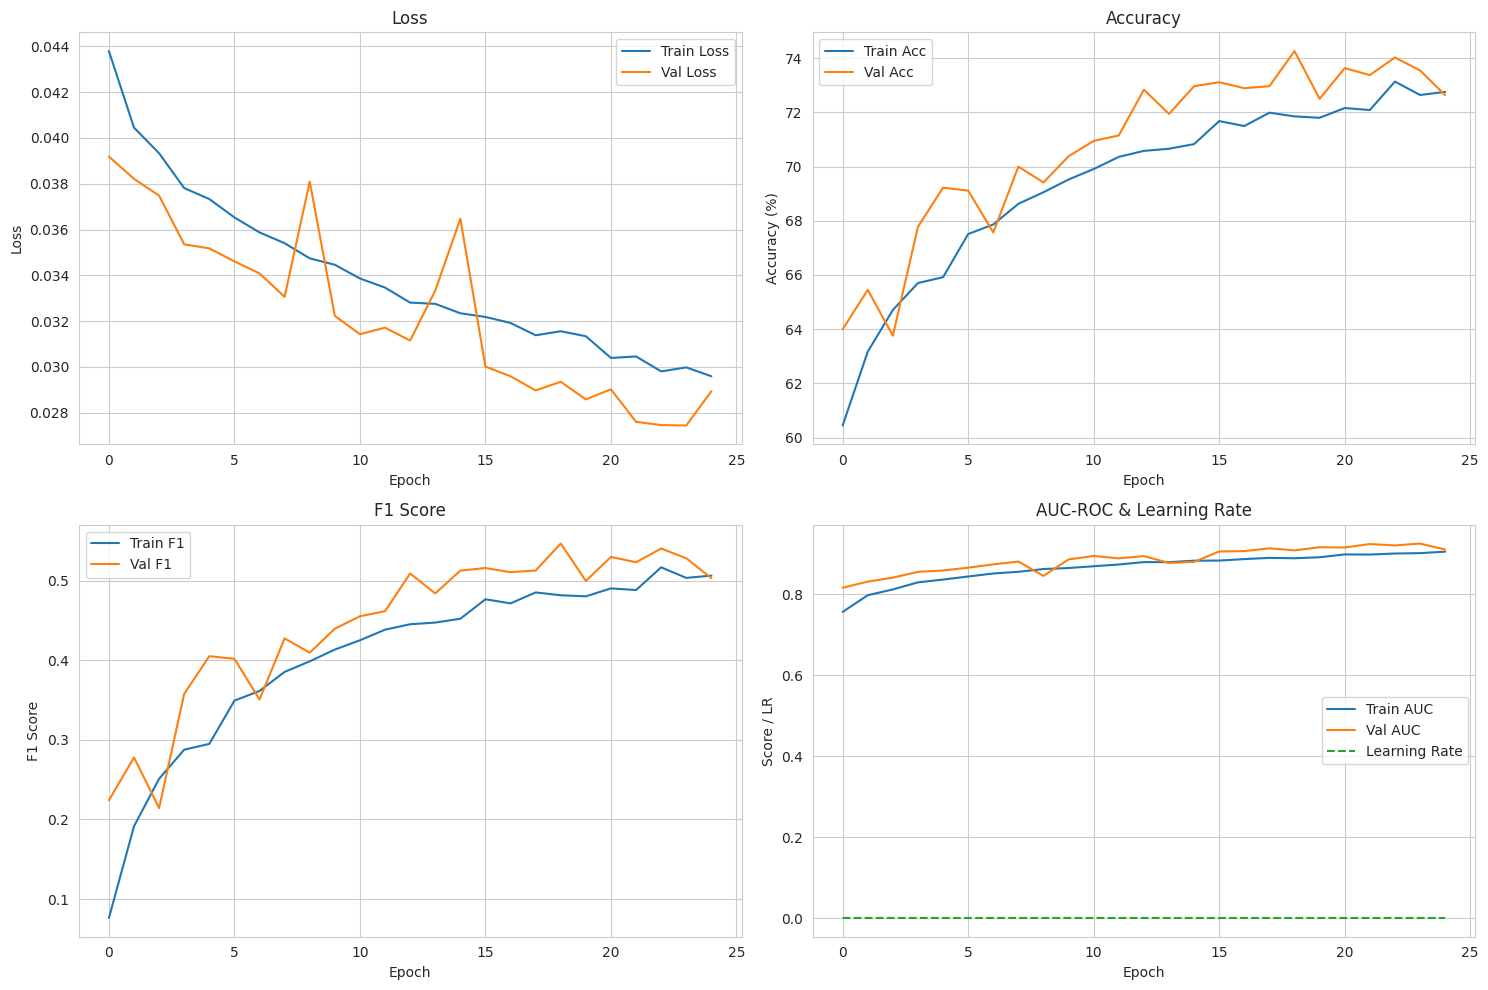


=== Final Evaluation ===
Best Validation Accuracy: 74.26%
Best Validation F1-Score: 0.5464
Best Validation AUC-ROC: 0.9255
Final Learning Rate: 0.000243
Total Epochs Trained: 25


In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=4.0, alpha=0.85):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        targets = targets.float()
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()

class SpikingNeuralNetwork(nn.Module):
    def __init__(self, input_channels, input_timesteps, hidden_size):
        super().__init__()
        self.input_weights = nn.Linear(input_channels, hidden_size)
        
        # Thêm 7 hidden layers
        self.hidden_layer1 = nn.Linear(hidden_size, hidden_size)
        self.hidden_layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.hidden_layer3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.hidden_layer4 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.hidden_layer5 = nn.Linear(hidden_size // 8, hidden_size // 16)
        self.hidden_layer6 = nn.Linear(hidden_size // 16, hidden_size // 32)
        self.hidden_layer7 = nn.Linear(hidden_size // 32, hidden_size // 64)
        
        self.output_layer = nn.Linear(hidden_size // 64, 1)

        # Batch Normalization
        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size)
        self.batch_norm3 = nn.BatchNorm1d(hidden_size // 2)
        self.batch_norm4 = nn.BatchNorm1d(hidden_size // 4)
        self.batch_norm5 = nn.BatchNorm1d(hidden_size // 8)
        self.batch_norm6 = nn.BatchNorm1d(hidden_size // 16)
        self.batch_norm7 = nn.BatchNorm1d(hidden_size // 32)

        self.dropout = nn.Dropout(0.5)

        # Tham số của neuron spiking
        self.tau_m = 20.0
        self.threshold = 0.55
        self.reset_potential = 0.0

    def forward(self, x):
        batch_size = x.shape[0]
        x_reshaped = x.reshape(-1, x.shape[-1])
        hidden_activations = self.input_weights(x_reshaped)
        hidden_activations = self.batch_norm1(hidden_activations)
        hidden_activations = hidden_activations.reshape(batch_size, -1, hidden_activations.shape[-1])

        # Cơ chế Spiking
        membrane_potential = torch.zeros(batch_size, hidden_activations.shape[-1], device=x.device)
        spikes = torch.zeros_like(hidden_activations)

        for t in range(x.shape[1]):
            membrane_potential = membrane_potential + (hidden_activations[:, t] - membrane_potential) / self.tau_m
            spike = (membrane_potential >= self.threshold).float()
            spikes[:, t] = spike
            membrane_potential = membrane_potential * (1 - spike) + self.reset_potential * spike

        avg_spikes = torch.mean(spikes, dim=1)
        avg_spikes = self.dropout(avg_spikes)

        # Qua các hidden layers
        hidden = torch.relu(self.batch_norm2(self.hidden_layer1(avg_spikes)))
        hidden = torch.relu(self.batch_norm3(self.hidden_layer2(hidden)))
        hidden = torch.relu(self.batch_norm4(self.hidden_layer3(hidden)))
        hidden = torch.relu(self.batch_norm5(self.hidden_layer4(hidden)))
        hidden = torch.relu(self.batch_norm6(self.hidden_layer5(hidden)))
        hidden = torch.relu(self.batch_norm7(self.hidden_layer6(hidden)))
        hidden = torch.relu(self.hidden_layer7(hidden))

        output = self.output_layer(hidden)
        return output.squeeze(-1)

class EEGClassifier:
    def __init__(self, input_channels, input_timesteps, hidden_size, device='cuda'):
        self.device = device
        self.model = SpikingNeuralNetwork(input_channels, input_timesteps, hidden_size).to(device)
        self.learning_rate = 0.0055
        self.batch_size = 126
        self.epochs = 25
        self.early_stop_acc = 95.0
        self.threshold = 0.7
        
        # Thêm các list để lưu metrics
        self.metrics = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'train_f1': [],
            'val_f1': [],
            'train_auc': [],
            'val_auc': [],
            'lr_history': []
        }

    def prepare_data(self, X, Y):
        X = torch.FloatTensor(X).permute(0, 2, 1).to(self.device)
        Y = torch.FloatTensor(Y).to(self.device)
        return DataLoader(dataset=TensorDataset(X, Y), batch_size=self.batch_size, shuffle=True)
    
    def train(self, train_loader, val_loader, class_weights):
        class_weights = torch.FloatTensor(class_weights).to(self.device)
        criterion = FocalLoss(alpha=class_weights[1])
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=3e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

        for epoch in range(self.epochs):
            self.model.train()
            train_loss, train_correct, train_total = 0, 0, 0
            train_preds, train_targets, train_outputs = [], [], []

            # Training loop
            for inputs, targets in train_loader:
                optimizer.zero_grad()
                output = self.model(inputs)
                loss = criterion(output, targets)
                loss.backward()
                optimizer.step()

                preds = (torch.sigmoid(output) > self.threshold).float()
                train_correct += (preds == targets).sum().item()
                train_total += targets.size(0)
                train_loss += loss.item()

                train_preds.extend(preds.cpu().numpy())
                train_targets.extend(targets.cpu().numpy())
                train_outputs.extend(torch.sigmoid(output).detach().cpu().numpy())

            # Calculate training metrics
            train_acc = 100 * train_correct / train_total
            train_f1 = f1_score(train_targets, train_preds)
            train_auc = roc_auc_score(train_targets, train_outputs)

            # Validation
            val_loss, val_acc, val_f1, val_auc, val_cm = self.evaluate(val_loader, criterion)

            # Store metrics
            self.metrics['train_loss'].append(train_loss / len(train_loader))
            self.metrics['val_loss'].append(val_loss)
            self.metrics['train_acc'].append(train_acc)
            self.metrics['val_acc'].append(val_acc)
            self.metrics['train_f1'].append(train_f1)
            self.metrics['val_f1'].append(val_f1)
            self.metrics['train_auc'].append(train_auc)
            self.metrics['val_auc'].append(val_auc)
            self.metrics['lr_history'].append(optimizer.param_groups[0]['lr'])

            # Print epoch results
            print(f'\nEpoch [{epoch+1}/{self.epochs}]')
            print(f'Train - Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%, '
                  f'F1: {train_f1:.4f}, AUC: {train_auc:.4f}')
            print(f'Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, '
                  f'F1: {val_f1:.4f}, AUC: {val_auc:.4f}')
            print(f'Confusion Matrix:\n{val_cm}')
            print(f'Learning Rate: {self.metrics["lr_history"][-1]:.6f}')

            scheduler.step()

            # Early stopping khi val_acc >= 95%
            if val_acc >= self.early_stop_acc:
                print(f"Early Stopping: Validation Accuracy reached {val_acc:.2f}% at epoch {epoch+1}")
                break

    def evaluate(self, val_loader, criterion):
        self.model.eval()
        correct, total, total_loss = 0, 0, 0
        all_preds, all_targets, all_outputs = [], [], []

        with torch.no_grad():
            for inputs, targets in val_loader:
                output = self.model(inputs)
                loss = criterion(output, targets)
                preds = (torch.sigmoid(output) > self.threshold).float()
                correct += (preds == targets).sum().item()
                total += targets.size(0)
                total_loss += loss.item()

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_outputs.extend(torch.sigmoid(output).detach().cpu().numpy())

        val_acc = 100 * correct / total
        val_f1 = f1_score(all_targets, all_preds)
        val_auc = roc_auc_score(all_targets, all_outputs)
        cm = confusion_matrix(all_targets, all_preds)
        return total_loss / len(val_loader), val_acc, val_f1, val_auc, cm

    def plot_results(self):
        fig, axs = plt.subplots(2, 2, figsize=(15, 10))
        
        # Loss
        axs[0, 0].plot(self.metrics['train_loss'], label='Train Loss')
        axs[0, 0].plot(self.metrics['val_loss'], label='Val Loss')
        axs[0, 0].set_title('Loss')
        axs[0, 0].set_xlabel('Epoch')
        axs[0, 0].set_ylabel('Loss')
        axs[0, 0].legend()

        # Accuracy
        axs[0, 1].plot(self.metrics['train_acc'], label='Train Acc')
        axs[0, 1].plot(self.metrics['val_acc'], label='Val Acc')
        axs[0, 1].set_title('Accuracy')
        axs[0, 1].set_xlabel('Epoch')
        axs[0, 1].set_ylabel('Accuracy (%)')
        axs[0, 1].legend()

        # F1 Score
        axs[1, 0].plot(self.metrics['train_f1'], label='Train F1')
        axs[1, 0].plot(self.metrics['val_f1'], label='Val F1')
        axs[1, 0].set_title('F1 Score')
        axs[1, 0].set_xlabel('Epoch')
        axs[1, 0].set_ylabel('F1 Score')
        axs[1, 0].legend()

        # AUC-ROC and Learning Rate
        axs[1, 1].plot(self.metrics['train_auc'], label='Train AUC')
        axs[1, 1].plot(self.metrics['val_auc'], label='Val AUC')
        axs[1, 1].plot(self.metrics['lr_history'], label='Learning Rate', linestyle='--')
        axs[1, 1].set_title('AUC-ROC & Learning Rate')
        axs[1, 1].set_xlabel('Epoch')
        axs[1, 1].set_ylabel('Score / LR')
        axs[1, 1].legend()

        plt.tight_layout()
        plt.show()

    def print_final_evaluation(self):
        print("\n=== Final Evaluation ===")
        print(f"Best Validation Accuracy: {max(self.metrics['val_acc']):.2f}%")
        print(f"Best Validation F1-Score: {max(self.metrics['val_f1']):.4f}")
        print(f"Best Validation AUC-ROC: {max(self.metrics['val_auc']):.4f}")
        print(f"Final Learning Rate: {self.metrics['lr_history'][-1]:.6f}")
        print(f"Total Epochs Trained: {len(self.metrics['train_loss'])}")

if __name__ == "__main__":
    # Load dữ liệu
    X = np.load("/kaggle/working/processed_eeg_spikes_balanced_70pct.npy", allow_pickle=True)
    Y = np.load("/kaggle/working/processed_labels_balanced_70pct.npy", allow_pickle=True)

    # Chia dữ liệu
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=42)

    # Tính class weights
    class_weights = compute_class_weight('balanced', classes=[0, 1], y=Y_train)

    # Thiết lập device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Khởi tạo mô hình
    classifier = EEGClassifier(input_channels=X.shape[1], input_timesteps=X.shape[2], hidden_size=1024, device=device)

    # Chuẩn bị data loaders
    train_loader = classifier.prepare_data(X_train, Y_train)
    val_loader = classifier.prepare_data(X_val, Y_val)

    # Huấn luyện mô hình
    classifier.train(train_loader, val_loader, class_weights)

    # Vẽ kết quả
    classifier.plot_results()

    # In đánh giá tổng thể
    classifier.print_final_evaluation()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import torch
import numpy as np

def evaluate_accuracy(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == targets).sum().item()
            total += targets.size(0)
    return 100 * correct / total

def evaluate_precision_recall_f1(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return precision, recall, f1

def evaluate_roc_auc(model, dataloader):
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            y_true.extend(targets.cpu().numpy())
            y_scores.extend(torch.sigmoid(outputs).cpu().numpy())

    auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'AUC-ROC: {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    return auc

def evaluate_confusion_matrix(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    
    # Vẽ heatmap cho confusion matrix
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red')
    
    plt.show()
    
    return cm

Validation Accuracy: 84.30%
Precision: 0.8479, Recall: 0.7539, F1-score: 0.7981


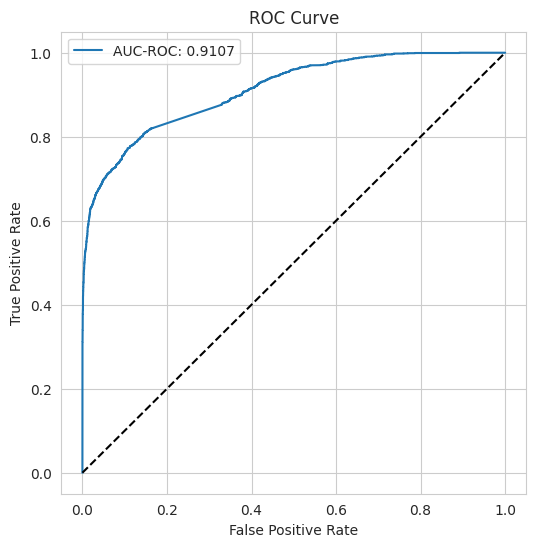

AUC-ROC: 0.9107


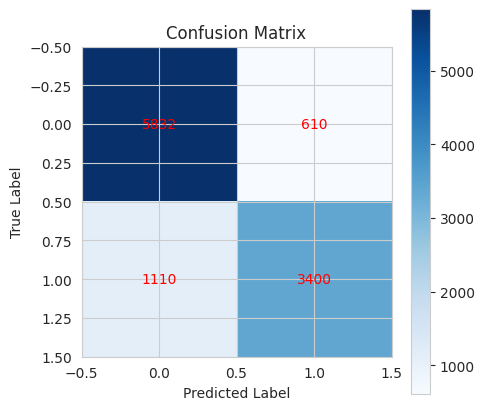

Confusion Matrix:
 [[5832  610]
 [1110 3400]]


In [12]:
# Đánh giá Accuracy
accuracy = evaluate_accuracy(classifier.model, val_loader)
print(f"Validation Accuracy: {accuracy:.2f}%")

# Đánh giá Precision, Recall, F1-score
precision, recall, f1 = evaluate_precision_recall_f1(classifier.model, val_loader)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

# Đánh giá AUC-ROC và vẽ đường cong ROC
auc = evaluate_roc_auc(classifier.model, val_loader)
print(f"AUC-ROC: {auc:.4f}")

# Vẽ Confusion Matrix
cm = evaluate_confusion_matrix(classifier.model, val_loader)
print("Confusion Matrix:\n", cm)

In [13]:
# Sau khi huấn luyện xong (thêm vào cuối __main__ hoặc chạy riêng)
torch.save(classifier.model.state_dict(), "snn_seizure_model.pth")
print("Mô hình đã được lưu vào 'snn_seizure_model.pth'")

Mô hình đã được lưu vào 'snn_seizure_model.pth'


In [14]:
# Khởi tạo lại mô hình giống hệt lúc huấn luyện
model = SpikingNeuralNetwork(input_channels=X.shape[1], input_timesteps=X.shape[2], hidden_size=1024)
model.load_state_dict(torch.load("snn_seizure_model.pth"))
classifier.model.eval()  # Chuyển sang chế độ đánh giá


SpikingNeuralNetwork(
  (input_weights): Linear(in_features=18, out_features=1024, bias=True)
  (hidden_layer1): Linear(in_features=1024, out_features=1024, bias=True)
  (hidden_layer2): Linear(in_features=1024, out_features=512, bias=True)
  (hidden_layer3): Linear(in_features=512, out_features=256, bias=True)
  (hidden_layer4): Linear(in_features=256, out_features=128, bias=True)
  (hidden_layer5): Linear(in_features=128, out_features=64, bias=True)
  (hidden_layer6): Linear(in_features=64, out_features=32, bias=True)
  (hidden_layer7): Linear(in_features=32, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
  (batch_norm1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm4): BatchNorm1d(256, eps=1e

Mô hình đã được tải từ 'snn_seizure_model.pth'
Các khoảng thời gian phát hiện co giật:
- Từ 3283.12 giây đến 3299.06 giây (khoảng 15.94 giây) - Xác suất trung bình: 87.98%


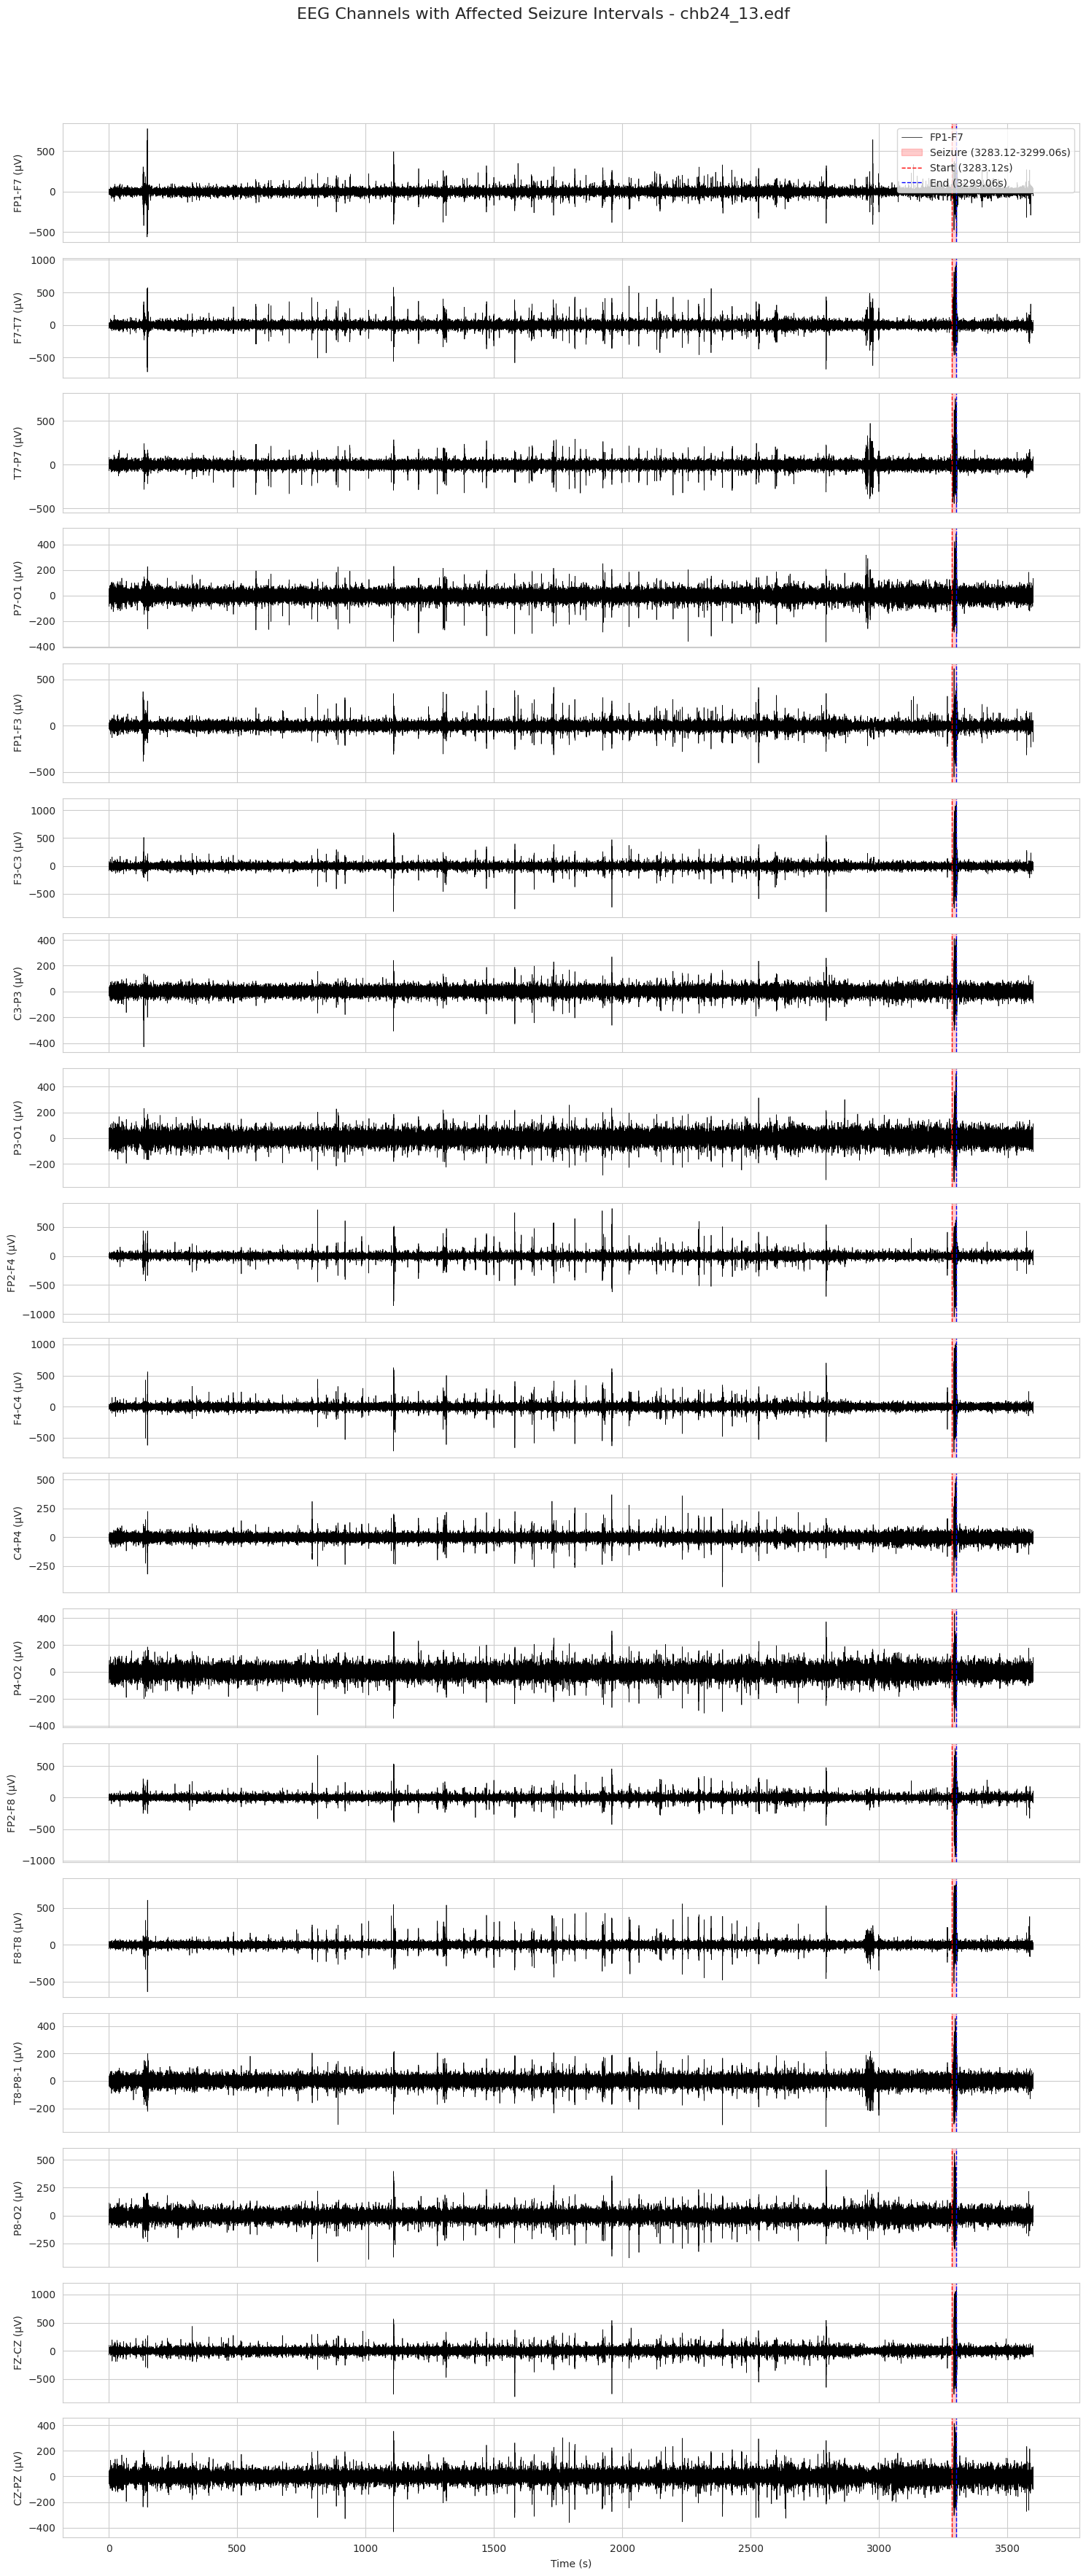

In [15]:
import torch
import torch.nn as nn
import numpy as np
import mne
from scipy.signal import resample
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Định nghĩa lớp SpikingNeuralNetwork
class SpikingNeuralNetwork(nn.Module):
    def __init__(self, input_channels, input_timesteps, hidden_size):
        super().__init__()
        self.input_weights = nn.Linear(input_channels, hidden_size)
        
        self.hidden_layer1 = nn.Linear(hidden_size, hidden_size)
        self.hidden_layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.hidden_layer3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.hidden_layer4 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.hidden_layer5 = nn.Linear(hidden_size // 8, hidden_size // 16)
        self.hidden_layer6 = nn.Linear(hidden_size // 16, hidden_size // 32)
        self.hidden_layer7 = nn.Linear(hidden_size // 32, hidden_size // 64)
        
        self.output_layer = nn.Linear(hidden_size // 64, 1)

        self.batch_norm1 = nn.BatchNorm1d(hidden_size)
        self.batch_norm2 = nn.BatchNorm1d(hidden_size)
        self.batch_norm3 = nn.BatchNorm1d(hidden_size // 2)
        self.batch_norm4 = nn.BatchNorm1d(hidden_size // 4)
        self.batch_norm5 = nn.BatchNorm1d(hidden_size // 8)
        self.batch_norm6 = nn.BatchNorm1d(hidden_size // 16)
        self.batch_norm7 = nn.BatchNorm1d(hidden_size // 32)

        self.dropout = nn.Dropout(0.45)

        self.tau_m = 20.0
        self.threshold = 0.55
        self.reset_potential = 0.0

    def forward(self, x):
        batch_size = x.shape[0]
        x_reshaped = x.reshape(-1, x.shape[-1])
        hidden_activations = self.input_weights(x_reshaped)
        hidden_activations = self.batch_norm1(hidden_activations)
        hidden_activations = hidden_activations.reshape(batch_size, -1, hidden_activations.shape[-1])

        membrane_potential = torch.zeros(batch_size, hidden_activations.shape[-1], device=x.device)
        spikes = torch.zeros_like(hidden_activations)

        for t in range(x.shape[1]):
            membrane_potential = membrane_potential + (hidden_activations[:, t] - membrane_potential) / self.tau_m
            spike = (membrane_potential >= self.threshold).float()
            spikes[:, t] = spike
            membrane_potential = membrane_potential * (1 - spike) + self.reset_potential * spike

        avg_spikes = torch.mean(spikes, dim=1)
        avg_spikes = self.dropout(avg_spikes)

        hidden = torch.relu(self.batch_norm2(self.hidden_layer1(avg_spikes)))
        hidden = torch.relu(self.batch_norm3(self.hidden_layer2(hidden)))
        hidden = torch.relu(self.batch_norm4(self.hidden_layer3(hidden)))
        hidden = torch.relu(self.batch_norm5(self.hidden_layer4(hidden)))
        hidden = torch.relu(self.batch_norm6(self.hidden_layer5(hidden)))
        hidden = torch.relu(self.batch_norm7(self.hidden_layer6(hidden)))
        hidden = torch.relu(self.hidden_layer7(hidden))

        output = self.output_layer(hidden)
        return output.squeeze(-1)

# Hàm chuẩn hóa và mã hóa xung
def normalize_data(X):
    X_min = X.min(axis=(0, 2), keepdims=True)
    X_max = X.max(axis=(0, 2), keepdims=True)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-8)
    return X_normalized

def rate_coding(signal, threshold=None, return_threshold=False):
    if threshold is None:
        threshold = np.mean(signal) + 2 * np.std(signal)
    spikes = np.zeros_like(signal)
    spikes[(signal > threshold) & (signal >= 0.65)] = 1
    if return_threshold:
        return spikes, threshold
    return spikes

# Hàm xử lý file EDF và dự đoán
def process_edf_for_prediction(file_path, ch_labels, time_window=14, time_step=4, downsample_factor=5, model=None, device='cuda'):
    mne.set_log_level(verbose='ERROR')
    edf = mne.io.read_raw_edf(file_path, preload=True)
    edf_labels = edf.ch_names

    if not all(any(ch in l for l in edf_labels) for ch in ch_labels):
        print(f"File {file_path} không chứa đủ các kênh yêu cầu.")
        edf.close()
        return None, None, None

    edf.pick(ch_labels)
    signals = edf.get_data() * 1e6  # Đơn vị: microvolts
    fs = int(1 / (edf.times[1] - edf.times[0]))
    total_timesteps = edf.n_times

    new_timesteps = total_timesteps // downsample_factor
    signals_downsampled = resample(signals, num=new_timesteps, axis=1)

    step_window = time_window * fs // downsample_factor
    step = time_step * fs // downsample_factor
    num_samples = (new_timesteps - step_window) // step + 1

    windows = np.zeros((num_samples, len(ch_labels), step_window), dtype=np.float32)
    timestamps = np.zeros(num_samples)

    for i in range(num_samples):
        start_idx = i * step
        windows[i, :, :] = signals_downsampled[:, start_idx:start_idx + step_window]
        timestamps[i] = start_idx * downsample_factor / fs

    windows = normalize_data(windows)
    windows = rate_coding(windows)

    windows_tensor = torch.FloatTensor(windows).permute(0, 2, 1).to(device)
    test_loader = DataLoader(TensorDataset(windows_tensor), batch_size=128, shuffle=False)

    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch[0]
            output = model(inputs)
            pred = torch.sigmoid(output).cpu().numpy()
            predictions.extend(pred)

    return timestamps, np.array(predictions), signals

# Hàm phát hiện thời gian co giật và tính phần trăm xác suất
def detect_seizure_times(timestamps, predictions, threshold=0.7, min_duration=7):
    seizure_intervals = []
    is_seizure = predictions > threshold
    start_time = None
    start_idx = None

    for i in range(len(timestamps)):
        if is_seizure[i] and start_time is None:
            start_time = timestamps[i]
            start_idx = i
        elif not is_seizure[i] and start_time is not None:
            end_time = timestamps[i-1]
            end_idx = i-1
            if end_time - start_time >= min_duration:
                seizure_probs = predictions[start_idx:end_idx+1]
                seizure_prob_mean = np.mean(seizure_probs) * 100
                seizure_intervals.append((start_time, end_time, seizure_prob_mean))
            start_time = None
            start_idx = None

    if start_time is not None:
        end_time = timestamps[-1]
        end_idx = len(timestamps)-1
        if end_time - start_time >= min_duration:
            seizure_probs = predictions[start_idx:end_idx+1]
            seizure_prob_mean = np.mean(seizure_probs) * 100
            seizure_intervals.append((start_time, end_time, seizure_prob_mean))

    return seizure_intervals

# Hàm xác định kênh bị ảnh hưởng trong mỗi khoảng co giật
def detect_affected_channels(signals, seizure_intervals, fs, amplitude_threshold_factor=2):
    affected_channels_per_interval = []
    time = np.arange(signals.shape[1]) / fs

    for start, end, prob in seizure_intervals:
        start_idx = int(start * fs)
        end_idx = int(end * fs)
        if end_idx > signals.shape[1]:
            end_idx = signals.shape[1]

        segment = signals[:, start_idx:end_idx]
        affected_channels = []

        for ch in range(signals.shape[0]):
            channel_signal = segment[ch]
            mean_signal = np.mean(signals[ch])
            std_signal = np.std(signals[ch])
            threshold = mean_signal + amplitude_threshold_factor * std_signal

            # Nếu có ít nhất 10% số điểm trong đoạn vượt ngưỡng, coi kênh bị ảnh hưởng
            if np.sum(np.abs(channel_signal) > threshold) / len(channel_signal) > 0.1:
                affected_channels.append(ch)

        affected_channels_per_interval.append((start, end, prob, affected_channels))

    return affected_channels_per_interval

# Hàm vẽ EEG với các kênh bị ảnh hưởng được đánh dấu riêng
def plot_eeg_with_seizures(signals, ch_labels, fs, seizure_intervals, file_name="EEG Plot"):
    num_channels = signals.shape[0]
    time = np.arange(signals.shape[1]) / fs

    # Xác định kênh bị ảnh hưởng
    affected_intervals = detect_affected_channels(signals, seizure_intervals, fs)

    fig, axes = plt.subplots(num_channels, 1, figsize=(15, 2 * num_channels), sharex=True)
    if num_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(time, signals[i], label=ch_labels[i], color='black', linewidth=0.5)
        ax.set_ylabel(f"{ch_labels[i]} (µV)")
        ax.grid(True)

        # Đánh dấu các khoảng co giật trên kênh bị ảnh hưởng
        for start, end, prob, affected_channels in affected_intervals:
            if i in affected_channels:
                ax.axvspan(start, end, color='red', alpha=0.2, label=f"Seizure ({start:.2f}-{end:.2f}s)" if i == affected_channels[0] else None)
            ax.axvline(x=start, color='red', linestyle='--', linewidth=1, label=f"Start ({start:.2f}s)" if i == 0 and start == affected_intervals[0][0] else None)
            ax.axvline(x=end, color='blue', linestyle='--', linewidth=1, label=f"End ({end:.2f}s)" if i == 0 and end == affected_intervals[0][1] else None)

    axes[0].legend(loc='upper right')
    axes[-1].set_xlabel("Time (s)")
    plt.suptitle(f"EEG Channels with Affected Seizure Intervals - {file_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Main execution
if __name__ == "__main__":
    ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 
                 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-1', 'P8-O2', 
                 'FZ-CZ', 'CZ-PZ']
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    input_channels = 18
    input_timesteps = 4096
    hidden_size = 1024
    loaded_model = SpikingNeuralNetwork(input_channels=input_channels, input_timesteps=input_timesteps, hidden_size=hidden_size).to(device)
    loaded_model.load_state_dict(torch.load("snn_seizure_model.pth", map_location=device))
    loaded_model.eval()
    print("Mô hình đã được tải từ 'snn_seizure_model.pth'")

    test_file_path = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_13.edf"
    timestamps, predictions, signals = process_edf_for_prediction(test_file_path, ch_labels, model=loaded_model, device=device)

    if timestamps is not None and predictions is not None and signals is not None:
        seizure_intervals = detect_seizure_times(timestamps, predictions, threshold=0.7, min_duration=5)
        if seizure_intervals:
            print("Các khoảng thời gian phát hiện co giật:")
            for start, end, prob in seizure_intervals:
                print(f"- Từ {start:.2f} giây đến {end:.2f} giây (khoảng {end - start:.2f} giây) - Xác suất trung bình: {prob:.2f}%")
        else:
            print("Không phát hiện cơn co giật nào trong file.")

        # Lấy tần số mẫu gốc từ file EDF
        edf = mne.io.read_raw_edf(test_file_path, preload=False)
        fs = int(1 / (edf.times[1] - edf.times[0]))
        edf.close()

        # Vẽ biểu đồ EEG với các kênh bị ảnh hưởng được đánh dấu
        plot_eeg_with_seizures(signals, ch_labels, fs, seizure_intervals, file_name="chb24_13.edf")

In [19]:
import torch
import numpy as np
import mne
from torch.utils.data import DataLoader, TensorDataset

# Load trained model
MODEL_PATH = "/kaggle/input/pthfile/snn_seizure_model.pth"  # Update with your model path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SpikingNeuralNetwork(torch.nn.Module):
    def __init__(self, input_channels, hidden_size):
        super().__init__()
        self.input_layer = torch.nn.Linear(input_channels, hidden_size)
        self.hidden_layer1 = torch.nn.Linear(hidden_size, hidden_size // 2)
        self.hidden_layer2 = torch.nn.Linear(hidden_size // 2, hidden_size // 4)
        self.output_layer = torch.nn.Linear(hidden_size // 4, 1)
    
    def forward(self, x):
        x = torch.relu(self.input_layer(x))
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        return torch.sigmoid(self.output_layer(x))

# Load Model
model = SpikingNeuralNetwork(input_channels=23, hidden_size=1024)  # Update input_channels if needed
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Load EEG Data (chb01_01.edf)
EDF_PATH = "chb01_01.edf"  # Update with actual file path
raw = mne.io.read_raw_edf(EDF_PATH, preload=True)
data = raw.get_data()
sfreq = raw.info["sfreq"]
timestamps = np.arange(data.shape[1]) / sfreq

# Preprocess EEG Data
def preprocess_eeg(data):
    data = (data - np.mean(data, axis=1, keepdims=True)) / np.std(data, axis=1, keepdims=True)
    return data.T  # Transpose to shape (timesteps, channels)

data = preprocess_eeg(data)

# Convert to PyTorch tensor
X_test = torch.FloatTensor(data).to(DEVICE)

# Run Prediction
with torch.no_grad():
    predictions = model(X_test).cpu().numpy().flatten()

# Print Predictions
threshold = 0.7  # Adjust based on training
seizure_predictions = (predictions > threshold).astype(int)

for i, pred in enumerate(seizure_predictions):
    if pred == 1:
        print(f"Possible Seizure at {timestamps[i]:.2f} seconds")

print("Prediction Complete ✅")


RuntimeError: Error(s) in loading state_dict for SpikingNeuralNetwork:
	Missing key(s) in state_dict: "input_layer.weight", "input_layer.bias". 
	Unexpected key(s) in state_dict: "input_weights.weight", "input_weights.bias", "hidden_layer3.weight", "hidden_layer3.bias", "hidden_layer4.weight", "hidden_layer4.bias", "hidden_layer5.weight", "hidden_layer5.bias", "hidden_layer6.weight", "hidden_layer6.bias", "hidden_layer7.weight", "hidden_layer7.bias", "batch_norm1.weight", "batch_norm1.bias", "batch_norm1.running_mean", "batch_norm1.running_var", "batch_norm1.num_batches_tracked", "batch_norm2.weight", "batch_norm2.bias", "batch_norm2.running_mean", "batch_norm2.running_var", "batch_norm2.num_batches_tracked", "batch_norm3.weight", "batch_norm3.bias", "batch_norm3.running_mean", "batch_norm3.running_var", "batch_norm3.num_batches_tracked", "batch_norm4.weight", "batch_norm4.bias", "batch_norm4.running_mean", "batch_norm4.running_var", "batch_norm4.num_batches_tracked", "batch_norm5.weig